In [66]:
#libraries
from pathlib import Path
import zipfile

import geopandas as gpd
import fiona
import matplotlib as plt
import matplotlib.pyplot as plt

import geojson
import json
import requests

import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show_hist
from rasterio.plot import show
from rasterio.merge import merge
from rasterio.crs import CRS
import numpy as np
from rasterio.windows import Window

import seaborn as sns
import pandas as pd
from scipy.ndimage import gaussian_filter

In [16]:
#directories
home_dir= Path(r"C:\Users\twand\Documents\Python\natural_capital")
raw_data_dir = home_dir / "data" / "raw"
proces_data_dir = home_dir / "data" / "processed"
external_data_dir = home_dir / "data" / "external"

### Functies

In [3]:
def gemeente_of_interest_geodf(gpkg_path: Path, layer_name: str | None, gemeente: str, output_path: Path) -> gpd.GeoDataFrame:
    """
    choose path, layername ('gemeenten', 'provincies', 'landsgrens') and gemeente to make a new geopandas dataframe
    """
    layers = fiona.listlayers(gpkg_path)

    if layer_name is None:
        print(f'no layer specified. Available layers: {layers}')
        layer_name = layers[0] #automatisch 'gemeente' layer
        print(f'setting default layer: {layer_name}')
    
    if layer_name not in layers:
        raise ValueError(f"Layer '{layer_name}' not found. Available layers: {layers}")
    
    gdf_layer = gpd.read_file(gpkg_path, layer=layer_name)
    chosen_gemeente = gdf_layer[gdf_layer['gemeentenaam'] == gemeente].copy()
    chosen_gemeente = chosen_gemeente.to_crs('EPSG:28992') #to Amersfoort coordinate system

    print(chosen_gemeente.crs)
    print(chosen_gemeente.describe)

    return chosen_gemeente.to_file(output_path)

In [4]:
def merge_raster_to_mosaic(input_folder, output_file, **kwargs):
    """
    Merges adjacent rasters to a big raster (mosaic)
    Accepts **kwargs for rasterio.merge (e.g., nodata=-9999)
    """
    RD_NEW = CRS.from_string("EPSG:28992")
    src_files_to_mosaic = []

    search_path = input_folder.glob("*.tif")

    for fp in search_path:
        src = rio.open(fp)
        src_files_to_mosaic.append(src)

    if not src_files_to_mosaic:
        print("Geen .tif bestanden gevonden in map!")
        return
    
    mosaic, out_trans = merge(src_files_to_mosaic, **kwargs) #RETRIEVE combined PIXEL_ARRAY and new GEOGRAPHIC_TRANSFORM
    
    show(mosaic, cmap='terrain')

    #kopieert en update metadata van de gemergde rasters
    out_meta = src.meta.copy()

    out_meta.update({"driver": "GTiff",
                    "height": mosaic.shape[1],
                    "width": mosaic.shape[2],
                    "transform": out_trans,
    })

    if not out_meta.get('crs'):
        out_meta.update({"crs": RD_NEW })
        print(f'geen CRS gevonden, EPSG:28992 (RD New) is toegewezen')
    else:
        print(f'bestaande CRS behouden:{out_meta['crs']}')

    if 'nodata' in kwargs:
        out_meta.update({"nodata": kwargs['nodata']})

    #write merged rasters with new meta-data to "tif_out_mosaic"
    with rio.open(output_file, "w", **out_meta) as dst:
        dst.write(mosaic)
    
    print(f'mosaic sucessfully created.\nSaved at location: {output_file}')

In [14]:
#Upscalen of downscalen

from rasterio.enums import Resampling

def resample_raster(input_path, output_path, target_res=0.5):
    """
    Past de resolutie van een raster aan naar een gewenste pixelgrootte (target_res).
    """

    with rio.open(input_path) as src:
        scale_factor = src.res[0] / target_res

        #Bereken de nieuwe dimensies
        new_height = int(src.height * scale_factor)
        new_width = int(src.width * scale_factor)

        #De data inlezen en herschalen
        data = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling = Resampling.average if scale_factor < 1 else Resampling.bilinear
        )

        #georeferentie bijwerken. Stapgrootte bijwerken, anders verschuift kaart
        new_transform = src.transform * src.transform.scale(
            src.width / data.shape[-1],
            src.height / data.shape[-2]
        )

        #Metadata voorbereiden voor het nieuwe bestand.
        out_meta = src.meta.copy()
        out_meta.update({
                    "driver": "GTiff",
                    "BIGTIFF": "YES",
                    "height": new_height,
                    "width": new_width,
                    "transform": new_transform,
                    "compress": "lzw", # LZW compressie houdt je bestanden klein zonder kwaliteitsverlies
                    "tiled": True
                })
        
        #  nieuwe bestand opslaan.
        with rio.open(output_path, "w", **out_meta) as dst:
            dst.write(data)
    
    print(f"Gereed: {output_path.name} is nu {target_res}m resolutie.")

In [6]:
import matplotlib.pyplot as plt
from rasterio.windows import Window
from rasterio.plot import show

def check_resampling(original_path, resampled_path, window_off=(6000, 3000), size_m=10):
    """
    VISUELE VALIDATIE VAN RESAMPLING:\n 
    Vergelijkt een specifiek gebied tussen het origineel en de resampled versie.
    size_m: grootte van de subset in meters.
    """
    with rio.open(original_path) as src_high, rio.open(resampled_path) as src_low:
        
        # 1. Bereken venster voor hoge resolutie (bijv. 8cm of 25cm)
        # We pakken een gebied van 'size_m' meter
        win_high = Window(window_off[0], window_off[1], 
                          int(size_m / src_high.res[0]), 
                          int(size_m / src_high.res[1]))
        
        # 2. Bereken venster voor lage resolutie (0.5m)
        # We moeten de offset schalen omdat er minder pixels zijn!
        scale = src_low.res[0] / src_high.res[0]
        win_low = Window(int(window_off[0] / scale), 
                         int(window_off[1] / scale), 
                         int(size_m / src_low.res[0]), 
                         int(size_m / src_low.res[1]))

        # Data inlezen
        data_high = src_high.read(1, window=win_high)
        data_low = src_low.read(1, window=win_low)

        # Plotten
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        show(data_high, ax=ax1, cmap='RdYlGn', title=f'Origineel ({src_high.res[0]}m)')
        show(data_low, ax=ax2, cmap='RdYlGn', title=f'Resampled ({src_low.res[0]}m)')

        plt.show()

        # Statistiek check
        print(f"--- Statistiek Vergelijking (Subset) ---")
        print(f"Origineel - Min: {data_high.min():.2f}, Max: {data_high.max():.2f}, Mean: {data_high.mean():.2f}")
        print(f"Resampled - Min: {data_low.min():.2f}, Max: {data_low.max():.2f}, Mean: {data_low.mean():.2f}")

In [ ]:
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
import json

def clip_raster_to_shape(input_raster_path, gemeente_geometry_path, output_name):
    """"
    Clips raster to a chosen shapefile or vector. 
    For example, aerial photo (RGB) clipped to municipality borders.
    """
    # 1. Lees het vectorbestand in vanaf het pad
    gdf = gpd.read_file(gemeente_geometry_path)

    with rio.open(input_raster_path) as src:
        original_names = src.descriptions
        print(f'band names: {original_names}')
        
        # 2. CRS Check: Heel belangrijk bij maskeren! 
        # Zorg dat de vorm dezelfde coördinatensysteem heeft als de TIF
        if gdf.crs != src.crs:
            print(f"Projectie omgezet van {gdf.crs} naar {src.crs}")
            gdf = gdf.to_crs(src.crs)

        # 3. Geometrie ophalen
        geometry_clip = [json.loads(gdf.to_json())["features"][0]["geometry"]]
        
        # 4. Maskeren (Clippen)
        out_image, out_transform = mask(src, shapes=geometry_clip, crop=True)

        # Omdat de mask functie het beeld bijsnijdt (crop=True), 
        # verschuift de linkerbovenhoek naar de rand van de geometrie. 
        # De out_transform registreert deze nieuwe, verschoven positie.
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "BIGTIFF": "YES",
            "tiled": True,
            "compress": "lzw" # Altijd handig voor grote bestanden
        })

        # 5. Wegschrijven
        with rio.open(output_name, "w", **out_meta) as dst:
            dst.write(out_image)
            dst.descriptions = original_names
        
    print(f'\nInput raster is clipped by {gemeente_geometry_path.name}.\nSaved as: {output_name}')
    # print('Preview:')

    # # PREVIEW LOGICA
    # print(f"Preview van Band 1 (van de {src.count} bands):")
    # show(out_image[0], cmap='terrain')

In [9]:
import rasterio as rio
from rasterio.windows import Window
import numpy as np
import logging

def create_feature_stack_windowed(output_path, ndsm_path, ndsm_path_gaus, ndvi_path, 
                                 rgb_path, infra_path, entropy_path, texture_path, gebouwen_path):
    
    # 1. Open alle bronnen tegelijk (lazy opening, kost bijna geen RAM)
    with rio.open(ndvi_path) as src_master, \
         rio.open(rgb_path) as src_rgb, \
         rio.open(infra_path) as src_nir, \
         rio.open(entropy_path) as src_ent, \
         rio.open(texture_path) as src_tex, \
         rio.open(ndsm_path) as src_ndsm, \
         rio.open(ndsm_path_gaus) as src_gaus, \
         rio.open(gebouwen_path) as src_geb:

        # 2. Metadata voorbereiden op basis van de Master (NDVI)
        master_meta = src_master.meta.copy()
        master_bounds = src_master.bounds
        h_master, w_master = src_master.height, src_master.width
        
        master_meta.update({
            "count": 10,
            "dtype": 'float32',
            "compress": 'lzw',
            "BIGTIFF": "YES",
            "tiled": True,
            "blockxsize": 256, # Optimaliseert voor QGIS
            "blockysize": 256
        })

        logging.info(f"Start windowed processing voor {output_path.name}")

        # 3. Maak het doelbestand aan
        with rio.open(output_path, "w", **master_meta) as dst:
            dst.descriptions = ['nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture', 'gebouwen']
            
            # 4. Loop over de blokken (windows) van de Master kaart
            # block_windows() geeft handige stukjes terug (bijv. 256x256 of 1024x1024)
            for ij, window in src_master.block_windows():
                
                # Afmetingen van dit specifieke venster
                win_h, win_w = window.height, window.width
                
                # Container voor dit venster maken (10 lagen)
                chunk = np.zeros((10, win_h, win_w), dtype='float32')

                # A. Direct inlezen (lagen die al 25cm/gealigneerd zijn)
                chunk[2] = src_master.read(1, window=window).astype('float32') # NDVI
                chunk[3:6] = src_rgb.read(window=window).astype('float32')     # R, G, B
                chunk[6] = src_nir.read(1, window=window).astype('float32')    # NIR
                chunk[7] = src_ent.read(1, window=window).astype('float32')    # Entropy
                chunk[8] = src_tex.read(1, window=window).astype('float32')    # Texture

                # B. Uitlijnen (lagen die mogelijk een andere extent hebben)
                # We bepalen de geografische bounds van dit SPECIFIEKE venster
                win_bounds = src_master.window_bounds(window)
                
                # Voor de externe lagen zoeken we het bijbehorende venster in HUN bestand
                for src_ext, idx in [(src_ndsm, 0), (src_gaus, 1), (src_geb, 9)]:
                    ext_window = src_ext.window(*win_bounds)
                    chunk[idx] = src_ext.read(1, window=ext_window, out_shape=(win_h, win_w)).astype('float32')

                # C. Maskeren: Gebouwen (Laag 9) op 0 zetten
                # gebouw_masker = chunk[9] > 0
                # chunk[0:9, gebouw_masker] = 0

                # D. Schrijf dit venster weg naar de grote TIF
                dst.write(chunk, window=window)

                # Optioneel: voortgang tonen per 100 blokken
                if ij[0] % 50 == 0 and ij[1] == 0:
                    logging.info(f"Voortgang: Rij {ij[0]} verwerkt...")
                    print(ij[0])

    logging.info(f"Gelukt! Stack opgeslagen: {output_path.name}")

In [9]:
import numpy as np
import rasterio
from skimage.color import rgb2gray
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy.ndimage import generic_filter, uniform_filter

def create_texture_entropy_layers(rgb_path, entropy_output_path, contrast_output_path, window_radius=3):
    # window_radius 3 = diameter ~7 pixels (dus vergelijkbaar met window_size=7)
    
    print("Bezig met inlezen...")
    with rasterio.open(rgb_path) as src:
        # Lees data en zet om naar Grayscale (0-255 uint8 is nodig voor rank filters)
        rgb_data = src.read([1, 2, 3])
        profile = src.profile #bv. projectie RD New, pixels zijn 0.5m groot, ik heb X rijen en Y kolommen
        
        # Transpose en grayscale
        rgb_reshaped = np.transpose(rgb_data, (1, 2, 0))
        gray_img = (rgb2gray(rgb_reshaped) * 255).astype(np.uint8)

    print("Berekenen Entropy (geoptimaliseerd)...")
    # Dit is C-code onder water. Veel sneller.
    # disk(3) maakt een cirkelvormig venster met radius 3
    entropy_map = entropy(gray_img, disk(window_radius))

    print("Berekenen 'Contrast' (via Standaard Deviatie)...")
    # TRUC: Standaard Deviatie is een super snelle benadering voor Contrast/Textuur
    # Formule: std = sqrt( E[x^2] - (E[x])^2 )
    
    img_float = gray_img.astype(float)
    c1 = uniform_filter(img_float, size=window_radius*2, mode='reflect')
    c2 = uniform_filter(img_float*img_float, size=window_radius*2, mode='reflect')
    std_map = np.sqrt(c2 - c1*c1)

    # Opslaan
    print("Opslaan...")
    profile.update(dtype=rasterio.float32, count=1)
    
    with rasterio.open(entropy_output_path, 'w', **profile) as dst:
        dst.write(entropy_map.astype(rasterio.float32), 1)
        
    with rasterio.open(contrast_output_path, 'w', **profile) as dst:
        dst.write(std_map.astype(rasterio.float32), 1)
        
    print("Klaar!")
    return entropy_output_path, contrast_output_path

In [24]:
import rasterio as rio
from rasterio import features, windows
import geopandas as gpd
import pandas as pd
import numpy as np
import os

def maak_training_dataset_tiled(raster_path, vector_path, output_csv_path):
    """
    Zet een satellietbeeld en een vectorbestand om naar een CSV voor Machine Learning.
    Verwerkt de data in kleine blokjes (tiles) om geheugenproblemen te voorkomen.
    """
    # 1: Voorbereiding bestanden
    if os.path.exists(output_csv_path):
        os.remove(output_csv_path)
        print(f"Oud bestand verwijderd: {output_csv_path}")

    vector_data = gpd.read_file(vector_path) #de gelabelde polygonen

    # 2: Labels van polygonen omzetten naar getallen
    kolom_namen = ['boom', 'gras', 'water_weg']
    name_to_num = {naam: i+1 for i, naam in enumerate(kolom_namen)}
    num_to_name = {v: k for k, v in name_to_num.items()}
    
    vector_data['label_naam'] = vector_data[kolom_namen].astype(float).idxmax(axis=1) #pakt de naam van de kolom die de hoogste waarde heef
    vector_data['label_nummer'] = vector_data['label_naam'].map(name_to_num) #converts text to the ID (name_to_num)
    
    print("Start met het verwerken van tegels (tiles)...")

    # 3: Satellietbeeld openen en verwerken
    with rio.open(raster_path) as satelliet_beeld:
        
        if vector_data.crs != satelliet_beeld.crs:
            print(f"Projecties verschillen. Vector wordt omgezet naar {satelliet_beeld.crs}")
            vector_data = vector_data.to_crs(satelliet_beeld.crs)
            
        band_namen = [satelliet_beeld.descriptions[i] or f"band_{i+1}" for i in range(satelliet_beeld.count)]
        
        is_eerste_blokje = True 

        # LOOP 
        for blok_index, venster in satelliet_beeld.block_windows(1):

            # A. in blokken laden
            venster_grenzen = windows.bounds(venster, satelliet_beeld.transform)
            xmin, ymin, xmax, ymax = venster_grenzen
            
            # B. zoek polygoon in blok
            polygonen_in_venster = vector_data.cx[xmin:xmax, ymin:ymax] #welke bomen zitten in dit venster?
            if polygonen_in_venster.empty:
                continue 

            # C. Rasteriseren: van de polygonen een grid maken met nummers (1=bomen 2=etc.)
            venster_transformatie = satelliet_beeld.window_transform(venster)
            vormen_en_labels = ((geom, waarde) for geom, waarde in zip(polygonen_in_venster.geometry, polygonen_in_venster['label_nummer']))
            
            label_masker = features.rasterize(
                shapes=vormen_en_labels,
                out_shape=(venster.height, venster.width),
                transform=venster_transformatie,
                fill=0,
                all_touched=True,
                dtype=rio.uint8
            )
            
            # D. Data Lezen
            pixel_data = satelliet_beeld.read(window=venster)
            
            # E. Plat slaan 3D (Height, Width, Bands) --> 2D (rows=Samples, columns=Features)
            aantal_banden = satelliet_beeld.count
            alle_pixel_waardes = pixel_data.reshape(aantal_banden, -1).T
            alle_pixel_labels = label_masker.reshape(-1)
                        
            # F. Haal de NoData waarde op. Vervang NoData door 0 in de hele array en Nan naar 0
            nodata_waarde = satelliet_beeld.nodata if satelliet_beeld.nodata is not None else -9999
            alle_pixel_waardes = alle_pixel_waardes.astype(float)
            alle_pixel_waardes[alle_pixel_waardes == nodata_waarde] = np.nan

            # G. Filteren. Maak mask om straks de <0 waardes weg te filteren.
            wel_data_masker = alle_pixel_labels > 0
            if wel_data_masker.sum() == 0:
                continue

            # Pas het filter toe. Bewaar de pixels waar label voor is (> 0).
            gefilterde_pixels = alle_pixel_waardes[wel_data_masker]
            gefilterde_labels = alle_pixel_labels[wel_data_masker]
            
            # H. Opslaan
            df_chunk = pd.DataFrame(gefilterde_pixels, columns=band_namen)
            df_chunk['label_id'] = gefilterde_labels
            df_chunk['label'] = df_chunk['label_id'].map(num_to_name)
            
            df_chunk.to_csv(output_csv_path, mode='a', header=is_eerste_blokje, index=False)
            is_eerste_blokje = False

    print(f"De dataset is opgeslagen als: {output_csv_path}")

In [23]:
def gaussian_blur_filter(ndsm_input_path, gaussian_output_path, sigma=2, buffer=5):

    # 1. Lees DSM (Het Oppervlak / Ruw)
    with rio.open(ndsm_input_path) as src_ndsm:

        out_meta = src_ndsm.meta.copy()
        out_meta.update({
            "dtype": "float32",
            "compress": "lzw",
            "BIGTIFF": "YES",   
            "tiled": True,       
            "blockxsize": 256,
            "blockysize": 256
        }) 

        windows_list = list(src_ndsm.block_windows(1))
        totaal_blokken = len(windows_list)

        with rio.open(gaussian_output_path, "w", **out_meta) as dst:
            for i, (block_index, venster) in enumerate(windows_list):

                padded_window = Window(
                    venster.col_off - buffer,
                    venster.row_off - buffer,
                    venster.width + 2*buffer,
                    venster.height + 2*buffer
                )

                img_padded = src_ndsm.read(1, window=padded_window, boundless=True, fill_value=0)
                img_padded[img_padded < -100] = 0
                img_padded = np.nan_to_num(img_padded, nan=0.0)

                blurred_padded = gaussian_filter(img_padded, sigma=sigma)
                blurred_padded[blurred_padded < 0] = 0

                final_block = blurred_padded[buffer:-buffer, buffer:-buffer]

                dst.write(final_block.astype('float32'), window=venster, indexes=1)

                if i % 100 == 0:
                    print(f"Blok {i+1}/{totaal_blokken} verwerkt...", end='\r')



    print(f"Succesvol opgeslagen: {gaussian_output_path}")

### Ophalen gemeentegrens & CBS buurtdata (Voor Ecosystem service beneficiaries)

In [12]:
#EENMALIG DOEN
gemeente_gpkg_path = raw_data_dir / "bestuurlijkegrenzen.gpkg"
layers = fiona.listlayers(gemeente_gpkg_path)
print(layers)

gemeente_of_interest_geodf(gpkg_path=gemeente_gpkg_path, 
                                            layer_name='gemeenten', 
                                            gemeente='Alblasserdam',
                                            output_path=proces_data_dir / "alblasserdam_shape.geojson")

['gemeenten', 'provincies', 'landsgrens']
EPSG:28992
<bound method NDFrame.describe of      code  gemeentenaam                                           geometry
314  0482  Alblasserdam  MULTIPOLYGON (((105906.013 428208.799, 105905....>


<Axes: >

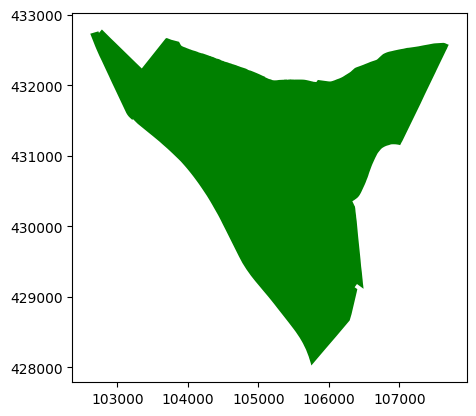

In [13]:
Alblasserdam_gdf = gpd.read_file(proces_data_dir / "alblasserdam_shape.geojson")
Alblasserdam_gdf.plot(color='green')

* collections → collection metadata → items → parameters.
* ga naar de landing page, nr 6: ""The JSON representation of the list of all data layers (collections) 
served from this endpoint" Klik daarop. Dan kom je op https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections.
* Er zijn hier drie collections: buurten/gemeenten/wijken. Hier staat: Bekijk collectie als JSON. 
* Daarin vind je dan weer: https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections/buurten
* Now you can fetch the actual data: https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections/buurten/items?f=json&limit=1000


### Ophalen boomhoogte rasterdata - niet meer nodig na random forest(?)

In [ ]:
# download zip file van boomhoogte data - EENMALIG UITVOEREN
url = "https://data.rivm.nl/data/alo/rivm_20240101_boomhoogte_2022.zip"
response = requests.get(url)
dest = raw_data_dir / "boom_hoogte.zip"

with open(dest, 'wb') as file:
    file.write(response.content)

#unpack zipfile and save
zip_path = raw_data_dir / "boom_hoogte_kaart_nl.zip"    #unzip
extract_dir = raw_data_dir / "boom_hoogte"              #destination path
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:               #write unzipped to destination
    z.extractall(extract_dir)

In [ ]:
#bomen kaart openen en snijden met gemeentevector - EENMALIG UITVOEREN VOOR EEN GEMEENTE
boom_raster_path = raw_data_dir / "boom_hoogte" / "rivm_20240101_boomhoogte_2022.tif"   
proces_data_dir.mkdir(parents=True, exist_ok=True)  #save folder

#load and inspect raster
with rio.open(boom_raster_path) as boom_raster:
    print(boom_raster.crs)
    print(boom_raster.count)
    print(boom_raster.meta)

    # Extract geometry from GeoDataFrame
    geom_alblas = [json.loads(Alblasserdam_gdf.to_json())["features"][0]["geometry"]]

    #clip raster to Alblasserdam
    out_image, out_transform = mask(
        boom_raster,
        shapes=geom_alblas,
        crop=True
    )

    #prepare metadata - Copy and update metadata
    out_meta = boom_raster.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Output file path
tif_path_alblas_bomen = proces_data_dir / "alblasserdam_bomen.tif"

# Write clipped raster
with rio.open(tif_path_alblas_bomen, "w", **out_meta) as dst:
    dst.write(out_image)

# tif_path_alblas_bomen

In [ ]:
# checken of bomenkaart is geladen
tif_path_alblas_bomen = proces_data_dir / "alblasserdam_bomen.tif"
with rio.open(tif_path_alblas_bomen) as clipped_bomen_Alblasserdam:
    # print(clipped_bomen_Alblasserdam.meta)
    show(clipped_bomen_Alblasserdam)

### LAZ data inladen

In [3]:
import os
import glob
import json
import subprocess

# Paden
input_dir = r"C:\Users\twand\Documents\Python\natural_capital\data\raw\puntenwolk\AHN5"
output_dir = r"C:\Users\twand\Documents\Python\natural_capital\data\processed"

os.makedirs(output_dir, exist_ok=True)

# Zoek alle .laz bestanden
point_clouds = glob.glob(os.path.join(input_dir, "*.laz"))

print(f"Start verwerking van {len(point_clouds)} bestanden (Alleen Gebouwen)...")

for pc in point_clouds:
    base_name = os.path.basename(pc).split('.')[0]
    output_file = os.path.join(output_dir, f"{base_name}_gebouwen_v2.tif")
    
    print(f" -> Bezig met: {base_name}")

    # Pipeline definitie
    pipeline = {
        "pipeline": [
            pc,
            {
                "type": "filters.range",
                "limits": "Classification[6:6]" # Alleen gebouwen
            },
            {
                "type": "writers.gdal",
                "filename": output_file,
                "resolution": "0.25",
                "output_type": "max",  
                "window_size": 0       # AANGEPAST: Geen gaten opvullen, strakke grenzen aanhouden
            }
        ]
    }
    # Direct uitvoeren via pipeline string (geen temp files nodig)
    process = subprocess.run(
        ["pdal", "pipeline", "--stdin"],
        input=json.dumps(pipeline),
        capture_output=True,
        text=True
    )

    if process.returncode == 0:
        print(f"    Gereed.")
    else:
        print(f"    Fout:\n{process.stderr}")

print("Alles voltooid.")

Start verwerking van 4 bestanden (Alleen Gebouwen)...
 -> Bezig met: 2023_C_38CN1
    Gereed.
 -> Bezig met: 2023_C_38CN2
    Gereed.
 -> Bezig met: 2024_C_38CZ1
    Gereed.
 -> Bezig met: 2024_C_38CZ2
    Gereed.
Alles voltooid.


### Data prep: Gebouwen, RGB data, Infra data, DMS data

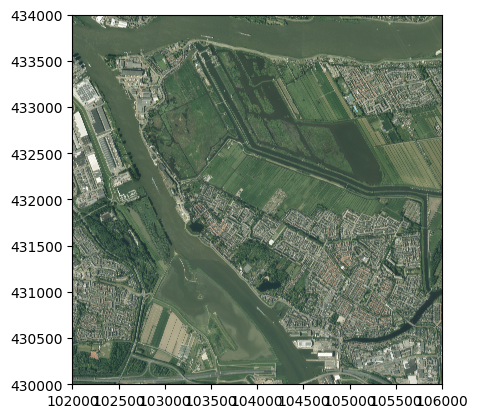

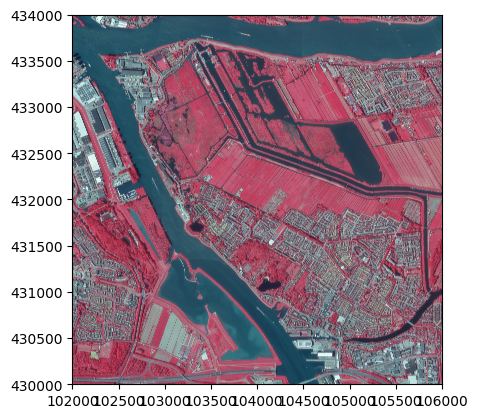

c:\Users\twand\Documents\Python\natural_capital\.venv\Lib\site-packages\matplotlib\colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


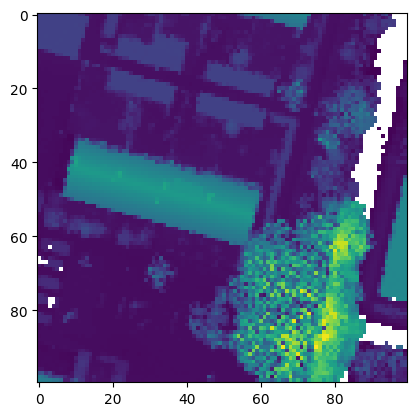

In [19]:
#TESTEN of data succesvol kan worden ingeladen.
ortho_raw = raw_data_dir / "ortho_alblasserdam025" / "2025_102000_434000_RGB_lrl.tif"
infra_raw = raw_data_dir / "infra_alblasserdam025" / "2025_102000_434000_CIR_lrl.tif"
dsm_raw = raw_data_dir / "surface_model_05" /"R_38CN1.tif"

with rio.open(ortho_raw) as ortho:
    show(ortho)

with rio.open(infra_raw) as infra:
    show(infra)

with rio.open(dsm_raw) as dsm:
    my_window = Window(col_off=6600, row_off=6000, width=100, height=100)
    subset_masked = dsm.read(1, window=my_window, masked=True)
    show(subset_masked)

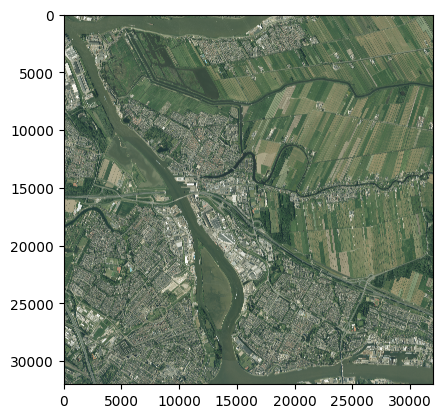

bestaande CRS behouden:EPSG:28992
mosaic sucessfully created.
Saved at location: C:\Users\twand\Documents\Python\natural_capital\data\processed\RGB_alblasser_regio25cm.tif


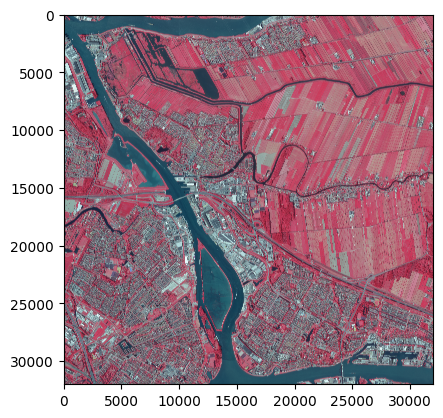

bestaande CRS behouden:EPSG:28992
mosaic sucessfully created.
Saved at location: C:\Users\twand\Documents\Python\natural_capital\data\processed\infra_alblasser_regio25cm.tif


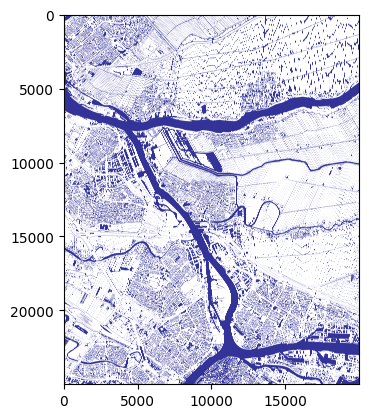

bestaande CRS behouden:EPSG:28992
mosaic sucessfully created.
Saved at location: C:\Users\twand\Documents\Python\natural_capital\data\processed\DTM05_alblasser_regio50cm.tif


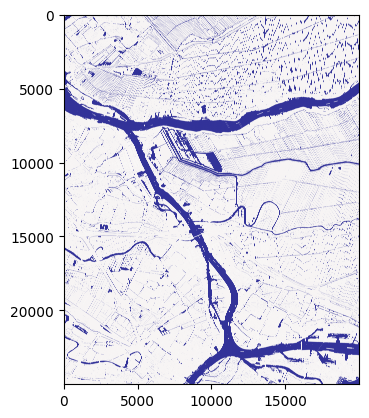

bestaande CRS behouden:EPSG:28992
mosaic sucessfully created.
Saved at location: C:\Users\twand\Documents\Python\natural_capital\data\processed\DSM05_alblasser_regio50cm.tif


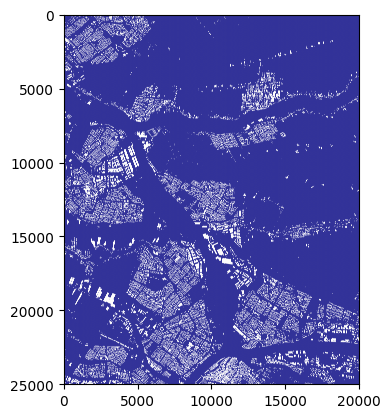

geen CRS gevonden, EPSG:28992 (RD New) is toegewezen
mosaic sucessfully created.
Saved at location: C:\Users\twand\Documents\Python\natural_capital\data\processed\gebouwen_alblasser_regio50cm.tif


In [21]:
#mergen van de vier ortho foto's (RGB en CIR) om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_rgb = raw_data_dir / "ortho_alblasserdam025"
tif_output_mosaic_rgb = proces_data_dir / "RGB_alblasser_regio25cm.tif"

tif_input_mosaic_infra = raw_data_dir / "infra_alblasserdam025"
tif_output_mosaic_infra = proces_data_dir / "infra_alblasser_regio25cm.tif"

merge_raster_to_mosaic(input_folder=tif_input_mosaic_rgb, 
                       output_file=tif_output_mosaic_rgb)


merge_raster_to_mosaic(input_folder=tif_input_mosaic_infra, 
                       output_file=tif_output_mosaic_infra)


#mergen van de twee hoogtemodellen (DTM-terrein en DSM-surface) om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_DTM05 = raw_data_dir / "terrain_model_05"     #EPSG:28992
tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_alblasser_regio50cm.tif"  #https://service.pdok.nl/rws/ahn/atom/dtm_05m.xml

tif_input_mosaic_DSM05 = raw_data_dir / "surface_model_05"     #EPSG:28992
tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_alblasser_regio50cm.tif"  #https://service.pdok.nl/rws/ahn/atom/dsm_05m.xml

merge_raster_to_mosaic(input_folder=tif_input_mosaic_DTM05, 
                       output_file=tif_output_mosaic_DTM05,
                       nodata=-9999.0)

merge_raster_to_mosaic(input_folder=tif_input_mosaic_DSM05, 
                       output_file=tif_output_mosaic_DSM05,
                       nodata=-9999.0)

#mergen van de PUNTENWOLKEN -> GEBOUWENRASTER om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_building = proces_data_dir / "gebouwen"
tif_output_mosaic_building = proces_data_dir / "gebouwen_alblasser_regio50cm.tif"

merge_raster_to_mosaic(input_folder=tif_input_mosaic_building, 
                       output_file=tif_output_mosaic_building,
                       nodata=-9999.0)


Shape van subset: (80, 80)


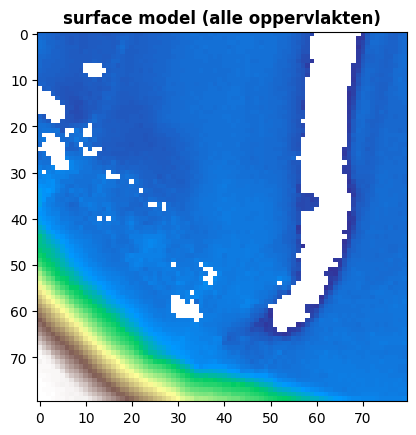

Shape van subset: (80, 80)


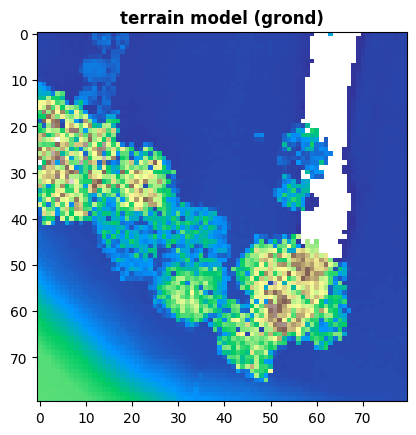

In [23]:
#TEST of de DTM en DSM kaarten (merged/mosaic) goed worden ingeladen
tif_output_mosaic_DSM05 = proces_data_dir / "DTM05_alblasser_regio50cm.tif"
tif_output_mosaic_DTM05 = proces_data_dir / "DSM05_alblasser_regio50cm.tif"

with rio.open(tif_output_mosaic_DSM05) as src:
    my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
    subset_masked = src.read(1, window=my_window, masked=True)

    print(f"Shape van subset: {subset_masked.shape}")
    show(subset_masked, cmap='terrain', contour=False, title='surface model (alle oppervlakten)')

with rio.open(tif_output_mosaic_DTM05) as src:
    my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
    subset_masked = src.read(1, window=my_window, masked=True)

    print(f"Shape van subset: {subset_masked.shape}")
    show(subset_masked, cmap='terrain', contour=False, title='terrain model (grond)')

In [24]:
#Berekenen van normalized DSM - EENMALIG UITVOEREN
tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_alblasser_regio50cm.tif"
tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_alblasser_regio50cm.tif"

# 1. Lees DSM (Het Oppervlak / Ruw)
with rio.open(tif_output_mosaic_DSM05) as src_dsm:
    dsm_data = src_dsm.read(1, masked=True)  
    out_meta = src_dsm.profile.copy()       # Kopieer metadata van de DSM voor de nieuwe nDSM laag

# 2. Lees DTM (Het Maaiveld / Kaal)
with rio.open(tif_output_mosaic_DTM05) as src_dtm:
    dtm_data = src_dtm.read(1, masked=True)

# 3. Bereken nDSM (Oppervlak - Maaiveld)
ndsm_data = dsm_data - dtm_data

# 4. Update de metadata
out_meta.update({
    "driver": "GTiff",
    "dtype": 'float32',       # Zeker weten dat we floats opslaan
    "nodata": -9999.0         # NoData waarde
})

tif_output_mosaic_ndsm = proces_data_dir / "nDSM_alblasser_regio50cm.tif"

# 5. Schrijf het bestand weg
with rio.open(tif_output_mosaic_ndsm, "w", **out_meta) as dst:
    dst.write(ndsm_data, 1)

print(f"Succesvol opgeslagen: {tif_output_mosaic_ndsm}")

Succesvol opgeslagen: C:\Users\twand\Documents\Python\natural_capital\data\processed\nDSM_alblasser_regio50cm.tif


--- Statistieken nDSM Subset ---
Minimale hoogte: -0.14 m
Maximale hoogte: 15.24 m
Gemiddelde hoogte: 1.41 m


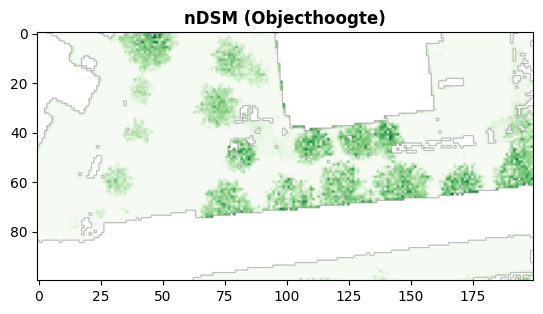

In [25]:
#TEST of nDSM werkt
tif_output_mosaic_ndsm = proces_data_dir / "nDSM_alblasser_regio50cm.tif"
my_window = Window(col_off=9450, row_off=11850, width=200, height=100) #klein stuk van de kaart inladen
with rio.open(tif_output_mosaic_ndsm) as src_ndsm:
    subset = src_ndsm.read(1, window=my_window, masked=True)

    print(f"--- Statistieken nDSM Subset ---")
    print(f"Minimale hoogte: {subset.min():.2f} m")
    print(f"Maximale hoogte: {subset.max():.2f} m")
    print(f"Gemiddelde hoogte: {subset.mean():.2f} m")
    
    show(subset, cmap='Greens', title='nDSM (Objecthoogte)')

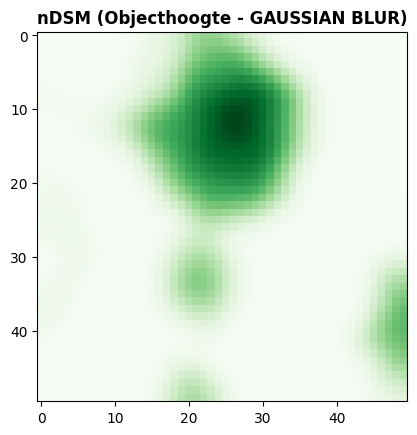

In [43]:
from scipy.ndimage import gaussian_filter
tif_output_mosaic_ndsm = proces_data_dir / "nDSM_alblasser_regio50cm.tif"
my_window = Window(col_off=9470, row_off=11840, width=50, height=50) #klein stuk van de kaart inladen
with rio.open(tif_output_mosaic_ndsm) as src_ndsm:
    subset_masked = src_ndsm.read(1, window=my_window, masked=True)
    subset_filled = subset_masked.filled(0)
    height_blurred = gaussian_filter(subset_filled, sigma=2)
    show(height_blurred, cmap='Greens', title='nDSM (Objecthoogte - GAUSSIAN BLUR)')

### texture en entropy kaart maken

In [48]:
# Uitvoeren
entropy_output_path = proces_data_dir / "RGB_texture_entropy_alblas_regio_25cm.tif"
contrast_output_path = proces_data_dir / "RGB_texture_std_alblas_regio_25cm.tif"

create_texture_entropy_layers(
    proces_data_dir / "RGB_alblasser_regio25cm.tif",
    entropy_output_path,
    contrast_output_path
)

Bezig met inlezen...
Berekenen Entropy (geoptimaliseerd)...
Berekenen 'Contrast' (via Standaard Deviatie)...


C:\Users\twand\AppData\Local\Temp\ipykernel_20080\2873410334.py:33: RuntimeWarning: invalid value encountered in sqrt
  std_map = np.sqrt(c2 - c1*c1)


Opslaan...
Klaar!


(WindowsPath('C:/Users/twand/Documents/Python/natural_capital/data/processed/RGB_texture_entropy_alblas_regio_25cm.tif'),
 WindowsPath('C:/Users/twand/Documents/Python/natural_capital/data/processed/RGB_texture_std_alblas_regio_25cm.tif'))

### NDVI kaartlaag maken

Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(0.25, 0.0, 102000.0,
       0.0, -0.25, 434000.0)}
pixelgrootte: 0.25
Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': C

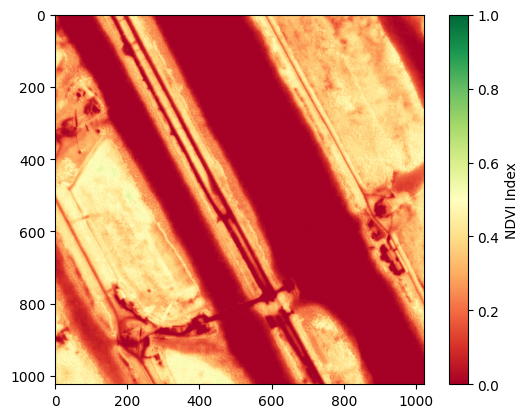

In [49]:
#CHECK of de berekening werkt
tif_input_mosaic_rgb = proces_data_dir / "RGB_alblasser_regio25cm.tif"
tif_input_mosaic_infra = proces_data_dir / "infra_alblasser_regio25cm.tif"

my_window = Window(col_off=6000, row_off=3000, width=1024, height=1024)

with rio.open(tif_input_mosaic_rgb) as src:
    print(f"Aantal bands: {src.count}")
    print(src.meta)
    red = src.read(1, window=my_window, masked=True).astype('float32')    #Band 1=R, 2=G, 3=B
    # show(red, title='red band ')
    print(f'pixelgrootte: {src.res[0]}')

with rio.open(tif_input_mosaic_infra) as src:
    print(f"Aantal bands: {src.count}")
    print(src.meta)
    nir = src.read(1, window=my_window, masked=True).astype('float32')
    # show(red, title='NIR band ')
    print(f'pixelgrootte: {src.res[0]}')


ndvi = (nir - red) / (nir + red + 1e-10)
# plt.imshow(ndvi, cmap='RdYlGn')
plt.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='NDVI Index')

Minimale waarde: -0.26
Maximale waarde: 0.69
Gemiddelde gemiddelde: 0.16


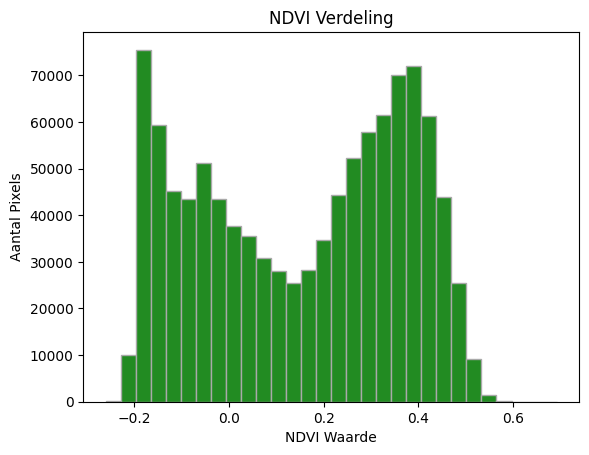

In [50]:
#check of de plots kloppen van de groenmaat (NDVI)
#graslanden of struikgewassen een NDVI waarde tussen de 0,2 en 0,4
#Bosvegetatie of hoogproductieve akkerbouw komen overeen met NDVI waardes hoger dan 0,4
#https://medium.com/@apratimonline/deep-dive-into-unsupervised-classification-of-satellite-images-k-means-pca-and-spectral-indices-442a5dc23219
print(f"Minimale waarde: {ndvi.min():.2f}")
print(f"Maximale waarde: {ndvi.max():.2f}")
print(f"Gemiddelde gemiddelde: {ndvi.mean():.2f}")
plt.hist(ndvi.compressed(), bins=30, color='forestgreen', edgecolor='darkgrey') # .compressed() is handig bij masked arrays: het verwijdert de NoData pixels
plt.title('NDVI Verdeling')
plt.xlabel('NDVI Waarde')
plt.ylabel('Aantal Pixels')
plt.show()

In [ ]:
import rasterio as rio
import numpy as np
import warnings

tif_input_mosaic_rgb = proces_data_dir / "RGB_alblasser_regio25cm.tif"
tif_input_mosaic_infra = proces_data_dir / "infra_alblasser_regio25cm.tif"
tif_output_NDVI_25cm = proces_data_dir / "NDVI_alblasser_regio25cm.tif"

# 1. Open beide bestanden tegelijk
with rio.open(tif_input_mosaic_rgb) as src_rgb, rio.open(tif_input_mosaic_infra) as src_nir:
    new_meta = src_rgb.meta.copy()

    # 2. Inlezen ZONDER masked=True (dit scheelt enorm veel RAM en tijd)
    red = src_rgb.read(1).astype('float32')
    nir = src_nir.read(1).astype('float32')

# 3. NDVI Berekening (Vectorized & Zonder Masked Arrays)
# We negeren tijdelijk de 'Divide by Zero' waarschuwing die numpy geeft bij lege pixels
with np.errstate(divide='ignore', invalid='ignore'):
    # De noemer
    noemer = nir + red
    
    # Gebruik np.where: Als de noemer 0 is (bijv. randen/nodata), vul -9999 in. 
    # Anders, bereken de NDVI. Dit is veel sneller dan + 1e-10 met masked arrays.
    ndvi = np.where(noemer == 0, -9999, (nir - red) / noemer)

# 4. Metadata updaten
new_meta.update({
    "driver": "GTiff",
    "dtype": "float32",     
    "count": 1,             
    "nodata": -9999,        
    "compress": "lzw"       
})

# 5. Wegschrijven
with rio.open(tif_output_NDVI_25cm, "w", **new_meta) as dst:
    dst.write(ndvi.astype('float32'), 1)

print(f"Succesvol: {tif_output_NDVI_25cm}")

Succesvol en razendsnel opgeslagen: C:\Users\twand\Documents\Python\natural_capital\data\processed\NDVI_alblasser_regio25cm.tif


### Samplen naar 25 cm

In [15]:
#resample DTM 50 cm naar 25 cm
resample_raster(proces_data_dir / "DTM05_alblasser_regio50cm.tif", 
                proces_data_dir / "DTM05_alblasser_regio25cm.tif", 
                target_res=0.25)

#resample DSM 50 cm naar 25 cm
resample_raster(proces_data_dir / "DSM05_alblasser_regio50cm.tif", 
                proces_data_dir / "DSM05_alblasser_regio25cm.tif", 
                target_res=0.25)

#resample nDSM 50 cm naar 25 cm
resample_raster(proces_data_dir / "nDSM_alblasser_regio50cm.tif", 
                proces_data_dir / "nDSM_alblasser_regio25cm.tif", 
                target_res=0.25)

#resample infra
resample_raster(proces_data_dir / "gebouwen_alblasser_regio50cm.tif", 
                proces_data_dir / "gebouwen_alblasser_regio25cm.tif",
                target_res=0.25)

Gereed: DTM05_alblasser_regio25cm.tif is nu 0.25m resolutie.
Gereed: DSM05_alblasser_regio25cm.tif is nu 0.25m resolutie.
Gereed: nDSM_alblasser_regio25cm.tif is nu 0.25m resolutie.
Gereed: gebouwen_alblasser_regio25cm.tif is nu 0.25m resolutie.


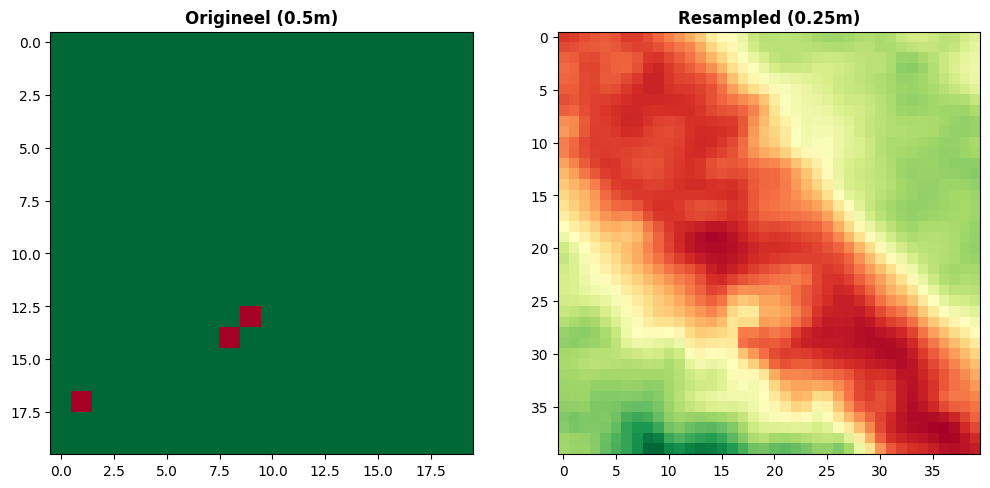

--- Statistiek Vergelijking (Subset) ---
Origineel - Min: -9999.00, Max: -1.41, Mean: -76.80
Resampled - Min: -2.07, Max: -1.43, Mean: -1.82


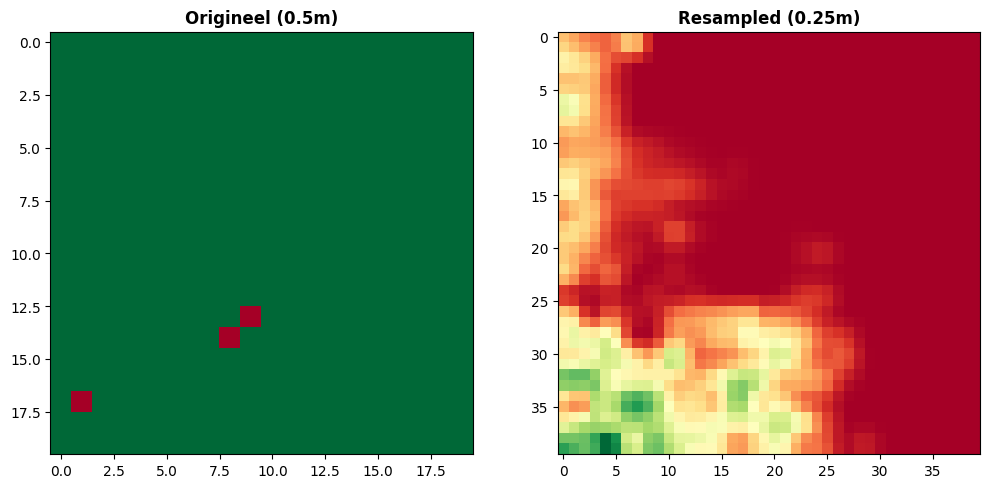

--- Statistiek Vergelijking (Subset) ---
Origineel - Min: -9999.00, Max: 6.83, Mean: -74.27
Resampled - Min: 0.00, Max: 5.48, Mean: 0.74


In [20]:
# CHECK Resample 
check_resampling(proces_data_dir / "DTM05_alblasser_regio50cm.tif", proces_data_dir / "DTM05_alblasser_regio25cm.tif")
check_resampling(proces_data_dir / "nDSM_alblasser_regio50cm.tif", proces_data_dir / "nDSM_alblasser_regio25cm.tif")

In [ ]:
with rio.open(proces_data_dir / "infra_05m.tif") as src:
    print(f"Aantal bands: {src.count}")      # Moet 3 zijn
    print(f"Bands: {src.indexes}")           # Moet (1, 2, 3) zijn
    print(f"Data type: {src.dtypes[0]}")     # Waarschijnlijk 'uint8' (0-255)

In [24]:
ndsm_input = proces_data_dir / "nDSM_alblasser_regio25cm.tif"
gaussian_output = proces_data_dir / "nDSM_gaus_s2b5_alblasser_regio25cm.tif"
gaussian_blur_filter(ndsm_input, gaussian_output)


Succesvol opgeslagen: C:\Users\twand\Documents\Python\natural_capital\data\processed\nDSM_gaus_s2b5_alblasser_regio25cm.tif


In [11]:
# ALLE RASTERS (ZELFDE RESOLUTIE 0.5M) STACKEN TOT ÉÉN LAAG
stack_path = proces_data_dir / "training_stack_alblasser_regio25cm.tif"
create_feature_stack_windowed(
    stack_path,
    proces_data_dir / "nDSM_alblasser_regio25cm.tif",
    proces_data_dir / "nDSM_gaus_s2b5_alblasser_regio25cm.tif",
    proces_data_dir / "NDVI_alblasser_regio25cm.tif",
    proces_data_dir / "RGB_alblasser_regio25cm.tif",
    proces_data_dir / "infra_alblasser_regio25cm.tif",
    proces_data_dir / "RGB_texture_entropy_alblas_regio_25cm.tif",
    proces_data_dir / "RGB_texture_std_alblas_regio_25cm.tif",
    proces_data_dir / "gebouwen_alblasser_regio25cm.tif"
)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
4100
4150
4200
4250
4300
4350
4400
4450
4500
4550
4600
4650
4700
4750
4800
4850
4900
4950
5000
5050
5100
5150
5200
5250
5300
5350
5400
5450
5500
5550
5600
5650
5700
5750
5800
5850
5900
5950
6000
6050
6100
6150
6200
6250
6300
6350
6400
6450
6500
6550
6600
6650
6700
6750
6800
6850
6900
6950
7000
7050
7100
7150
7200
7250
7300
7350
7400
7450
7500
7550
7600
7650
7700
7750
7800
7850
7900
7950
8000
8050
8100
8150
8200
8250
8300
8350
8400
8450
8500
8550
8600
8650
8700
8750
8800
8850
8900
8950
9000
9050
9100
9150
9200
9250
9300
9350
9400
9450
9500
9550
9600
9650
9700
9750
9800
9850
9900
9950
10000
10050
10100
10150

### Clip alle inputrasters naar gemeenteshape (nog even niet. Eerst gehele kaartlaag)

In [ ]:
training_data_input = proces_data_dir / "training_stack_05m_v2.tif"
alblasserdam_shape = proces_data_dir / "alblasserdam_shape.geojson"
alblasserdam_testing_stack = proces_data_dir / "alblasserdam_testing_stack_v2.tif"

clip_raster_to_shape(input_raster_folder=training_data_input,
                     gemeente_geometry=Alblasserdam_gdf,
                     output_name=alblasserdam_testing_stack)

# with rio.open(alblasserdam_rgb) as clipped_infra_alblas:
#     # print(clipped_bomen_Alblasserdam.meta)
#     show(clipped_infra_alblas)

### Random forest model maken
* Er is geen goede bomenkaart op gemeenteniveau. Enkel grote gemeentes hebben accurate data van hun bomenbestand. Daarom, o.b.v. diverse type satellietbeelden kunnen we een inferentie doen van welke pixels 'boom' zijn en welke niet.
* Hiervoor moet eerst trainingsdata worden gelabeld in Qgis zodat het model wat voorbeelden heeft. 
* Vervolgens inferentie van 'Boompixels' die we schatten met RFM. Vervolgens pixels samenvoegen tot 'boom' eenheden

In [21]:
class_cols = ['boom', 'gras', 'water_weg','geometry']

In [22]:
import geopandas as gpd
# Lees alleen de eerste rij om de kolomnamen te checken
check_data = gpd.read_file(external_data_dir / "bomenlabels_21022026.gpkg", rows=1)
print("De kolommen in jouw GPKG zijn:")
print(check_data.columns.tolist())

De kolommen in jouw GPKG zijn:
['boom', 'gras', 'water_weg', 'geometry']


In [25]:
training_df = maak_training_dataset_tiled(
    raster_path=proces_data_dir / "training_stack_alblasser_regio25cm.tif",
    vector_path=external_data_dir / "bomenlabels_21022026.gpkg", #de polygonen/vectors zijn in QGIS gelabelled
    output_csv_path=proces_data_dir / "bomen_training_dataset21022026.csv"
)

C:\Users\twand\AppData\Local\Temp\ipykernel_14760\4289830304.py:25: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  vector_data['label_naam'] = vector_data[kolom_namen].astype(float).idxmax(axis=1) #pakt de naam van de kolom die de hoogste waarde heef


Start met het verwerken van tegels (tiles)...
De dataset is opgeslagen als: C:\Users\twand\Documents\Python\natural_capital\data\processed\bomen_training_dataset21022026.csv


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
import pandas as pd

In [28]:
#inladen trainingsdata
training_csv = proces_data_dir / "bomen_training_dataset21022026.csv"
training_df = pd.read_csv(training_csv)

In [31]:
training_df.shape

(11939971, 12)

In [ ]:
training_df_no_buildings = training_df[training_df['gebouwen'].isna()]
training_df_no_buildings.shape #12.000 pixels (zo'n 750 vierkante meter) van de getekende boom- of graspolygonen vieln over een gebouw heen

(11927880, 12)

In [37]:
#Beschrijvende statistiek en paar samples bekijken
print(training_df_no_buildings.shape)
print(training_df_no_buildings.sample(5))
print(training_df_no_buildings.label.value_counts())

(11927880, 12)
            nDSM  nDSM_Gaussian      NDVI    Red  Green  Blue   NIR   entropy  \
11417943     NaN       0.000000 -0.366667   82.0   99.0  81.0  38.0  2.239073   
6905043   0.0000       0.000000 -0.342282  100.0  112.0  90.0  49.0  2.689227   
7073911   0.0000       0.000000  0.527559   30.0   53.0  47.0  97.0  3.400579   
3866175   5.7453       4.539776 -0.112299  104.0  117.0  97.0  83.0  4.444188   
7422213      NaN       0.000000 -0.368421   91.0  105.0  88.0  42.0  2.748972   

            texture  gebouwen  label_id      label  
11417943   1.421560       NaN         3  water_weg  
6905043    2.501234       NaN         3  water_weg  
7073911    3.147971       NaN         2       gras  
3866175   36.332939       NaN         3  water_weg  
7422213    1.683251       NaN         3  water_weg  
label
water_weg    9360039
gras         1810559
boom          757282
Name: count, dtype: int64


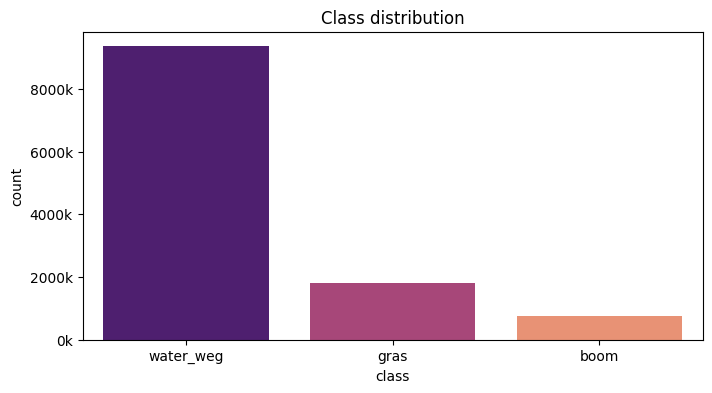

In [38]:
#class imbalance onderzoeken
plt.figure(figsize=(8,4))

ax = sns.countplot(x='label', data=training_df_no_buildings, hue='label', palette='magma')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

plt.title('Class distribution')
plt.xlabel('class')
plt.ylabel('count')
plt.show()


In [40]:
#resample class imbalance
def manual_undersample(df, label_col='label_id'):
    min_size = training_df[label_col].value_counts().min()
    print(f'minimum size for balanced dataset is {min_size} samples')
    balanced_df = training_df.groupby(label_col).sample(n=min_size, random_state=87)
    
    return balanced_df.sample(frac=1).reset_index(drop=True)

df_balanced = manual_undersample(training_df_no_buildings)
print(df_balanced.groupby(['label', 'label_id']).size())

minimum size for balanced dataset is 758644 samples
label      label_id
boom       1           758644
gras       2           758644
water_weg  3           758644
dtype: int64


In [45]:
X = df_balanced.drop(['label_id', 'label', 'gebouwen'], axis=1)
y = df_balanced['label_id']

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [47]:
#split train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
#transformeer kolumn namen naar werkbare lijst voor Scikit-learn pipeline ColumnTransformer
numeric_features = X_train.columns.tolist()
print(numeric_features)

['nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture']


In [49]:
#imputer instellen voor missende data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    ])

In [50]:
#preprocessor pipeline maken
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
        ])

In [51]:
#pipeline bouwen
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=87))
])

In [52]:
#model runnen en beste estimators kiezen voor final model
cv = KFold(n_splits=5, shuffle=True, random_state=5)

param_grid = {
    'classifier__learning_rate': [0.1],                 # 0.1 is de standaard, 0.05 is voorzichtiger
    'classifier__max_iter': [200],                 # Meer iteraties is vaak beter bij boosting
    'classifier__max_leaf_nodes': [100, ],             # 31 is default, 63 maakt complexere bomen
    'classifier__l2_regularization': [0.1]           # Helpt tegen overfitting bij nDSM uitschieters
}

estimator = GridSearchCV(pipe,
                          param_grid,
                          scoring='accuracy',
                          cv=5,
                          n_jobs=4,
                          verbose=3)

#Fitten en Scoren
estimator.fit(X_train, y_train)
print(f'beste params:{estimator.best_params_}')
print(f'test score: {estimator.score(X_test, y_test)} ' )

Fitting 5 folds for each of 1 candidates, totalling 5 fits
beste params:{'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_iter': 200, 'classifier__max_leaf_nodes': 100}
test score: 0.9943825284992761 


In [53]:
best_model = estimator.best_estimator_
y_pred = best_model.predict(X_test)

In [54]:
result = pd.DataFrame(estimator.cv_results_)
result.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__l2_regularization,param_classifier__learning_rate,param_classifier__max_iter,param_classifier__max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,64.020661,14.637356,7.254474,0.764802,0.1,0.1,200,100,"{'classifier__l2_regularization': 0.1, 'classi...",0.994362,0.994184,0.994241,0.994417,0.99428,0.994297,0.000084,1


In [55]:
performance_table = result.groupby(['param_classifier__learning_rate', 'param_classifier__max_iter', 'param_classifier__max_leaf_nodes'])[['mean_test_score']].mean()
performance_table

,,,mean_test_score
param_classifier__learning_rate,param_classifier__max_iter,param_classifier__max_leaf_nodes,
0.1,200,100,0.994297


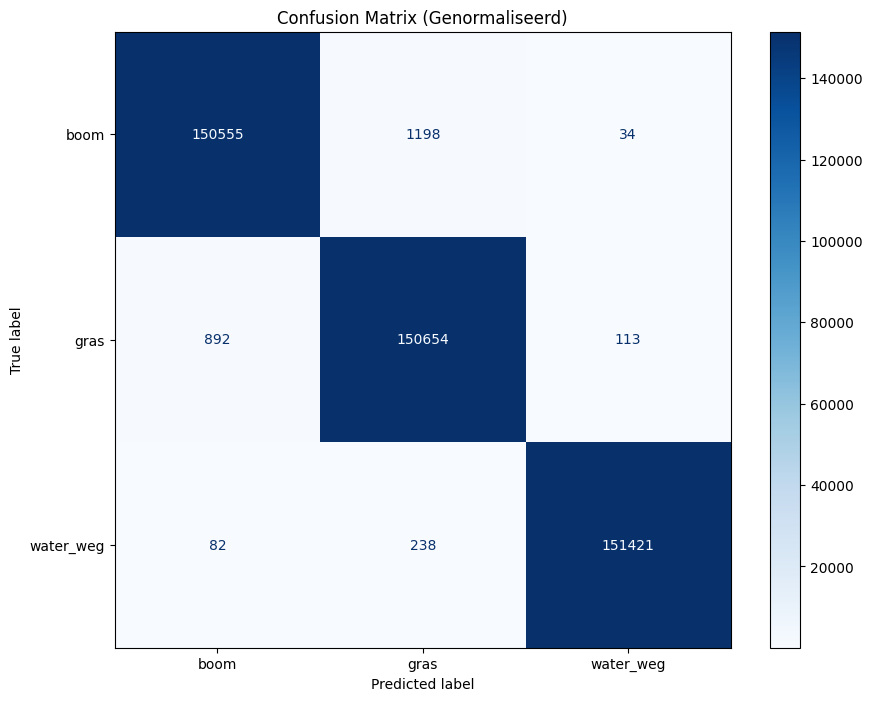

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Maak de plot direct vanuit het model
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_estimator(
    best_model, 
    X_test, 
    y_test, 
    display_labels=['boom', 'gras', 'water_weg'], # Of gebruik je dict: num_to_name.values()
    cmap='Blues',
    # normalize='true', # 'true' toont percentages, laat weg voor aantallen
    ax=ax
)

plt.title("Confusion Matrix (Genormaliseerd)")
plt.show()

### Twijfelgevallen analyse

In [60]:
print(best_model.classes_)
num_to_label = {1: 'boom', 2: 'gras', 3: 'water_weg'}
target_id = best_model.classes_[0]
target_label = num_to_label[target_id]
print(f"Index 1 in predict_proba hoort bij ID {target_id}, oftewel: {target_label}")
print(X_test.columns)

[1 2 3]
Index 1 in predict_proba hoort bij ID 1, oftewel: boom
Index(['nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR',
       'entropy', 'texture'],
      dtype='object')


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

#nieuwe DF maken met probabilities
boom_evaluatie_df = X_test.copy()

boom_evaluatie_df['ground_truth_id'] = y_test.values
boom_evaluatie_df['voorspelt_id'] = y_pred
boom_evaluatie_df['kans_boom'] = best_model.predict_proba(X_test)[:, 0] 

#labels terugplakken (nu codes. Zie num_to_label,)
boom_evaluatie_df['ground_truth'] = boom_evaluatie_df['ground_truth_id'].map(num_to_label)
boom_evaluatie_df['voorspelt'] = boom_evaluatie_df['voorspelt_id'].map(num_to_label)
boom_evaluatie_df['correct'] = np.where(boom_evaluatie_df['ground_truth'] != boom_evaluatie_df['voorspelt'], 'slecht_voorspelt', 'goed_voorspelt')

# Filteren op twijfelgevallen
twijfelgevallen = boom_evaluatie_df[boom_evaluatie_df['kans_boom'].between(0.45, 0.65)]
print(f"Aantal twijfelgevallen: {len(twijfelgevallen)}")

#filteren op twijfelgevallen enkel slecht voorpelde
twijfelgevallen_slecht = boom_evaluatie_df.loc[
    (boom_evaluatie_df['kans_boom'].between(0.45, 0.65)) & 
    (boom_evaluatie_df['correct'] == 'slecht_voorspelt')
]
print(f"Aantal twijfelgevallen (slecht): {len(twijfelgevallen_slecht)}")

features_to_check = ['nDSM', 'NDVI', 'kans_boom'] 
print("\nGemiddelde waardes van twijfelgevallen:")
print(twijfelgevallen_slecht[features_to_check].mean())
print("\nCheck van eerste 10 twijfelgevallen:")
print(twijfelgevallen_slecht[features_to_check + ['ground_truth', 'voorspelt', 'correct']].sample(5))


analysis = twijfelgevallen_slecht.groupby(['ground_truth', 'voorspelt']).agg(
    count=('correct', 'size'),
    avg_NDSM=('nDSM', 'mean'),
    avg_NDVI=('NDVI', 'mean'),
    avg_NDSM_gaus=('nDSM_Gaussian', 'mean')
)

print(analysis)



Aantal twijfelgevallen: 950
Aantal twijfelgevallen (slecht): 419

Gemiddelde waardes van twijfelgevallen:
nDSM         1.874654
NDVI         0.366891
kans_boom    0.546767
dtype: float64

Check van eerste 10 twijfelgevallen:
             nDSM      NDVI  kans_boom ground_truth voorspelt  \
1456064  3.177925  0.449057   0.549678         gras      boom   
1227193 -0.024587  0.355556   0.633961         gras      boom   
146079   0.782675  0.389121   0.562066         gras      boom   
296627        NaN  0.428571   0.461822         boom      gras   
914225   0.335800  0.433333   0.600692         gras      boom   

                  correct  
1456064  slecht_voorspelt  
1227193  slecht_voorspelt  
146079   slecht_voorspelt  
296627   slecht_voorspelt  
914225   slecht_voorspelt  
                        count  avg_NDSM  avg_NDVI  avg_NDSM_gaus
ground_truth voorspelt                                          
boom         gras         110  1.490518  0.383000       0.844758
             water_we

### Beste model maken en opslaan

In [62]:
import joblib
model_path = home_dir / "src"

final_model = estimator.best_estimator_
model_bestandsnaam = model_path / "hgbc_model_drechtsteden_v3.pkl"
joblib.dump(final_model, model_bestandsnaam)

print(f'bestand opgeslagen in {model_path}' )

bestand opgeslagen in C:\Users\twand\Documents\Python\natural_capital\src


### Bomen herkennen -  inferentie op Alblasserdam

band names: ('nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture', 'gebouwen')

Input raster is clipped by alblasserdam_shape.geojson.
Saved as: alblasserdam_testing_stack_21022026.tif
Preview:
Preview van Band 1 (van de 10 bands):


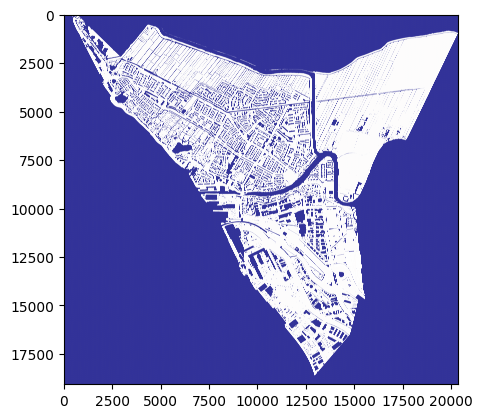

In [ ]:
clip_raster_path = proces_data_dir / "training_stack_alblasser_regio25cm.tif"
gemeente_geom = proces_data_dir / "alblasserdam_shape.geojson"
output_name = proces_data_dir / "alblasserdam_testing_stack_21022026.tif"
clip_raster_to_shape(clip_raster_path, gemeente_geom, output_name)

In [84]:
import rasterio as rio
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

# --- 1. PADEN & MODEL INLADEN ---
model_path = home_dir / "src"
hgbc_from_joblib = joblib.load(model_path / "hgbc_model_drechtsteden_v3.pkl")
alblasserdam_testing_stack = proces_data_dir / "alblasserdam_testing_stack_21022026.tif"
output_11_layers = proces_data_dir / "Alblasserdam_Inference_Stack_22022026.tif"

with rio.open(alblasserdam_testing_stack) as src:
    feature_namen = list(src.descriptions)
    
    # Haal de index van de boom-klasse en gebouwen-laag op
    boom_class_index = list(hgbc_from_joblib.classes_).index(1)
    gebouw_idx = feature_namen.index('gebouwen')
    
    # De 9 features die we echt opslaan (zonder gebouwen)
    opslaan_namen = [f for f in feature_namen if f != 'gebouwen']
    model_features = list(getattr(hgbc_from_joblib, 'feature_names_in_', opslaan_namen))

    windows_list = list(src.block_windows(1))
    totaal_blokken = len(windows_list)

    # --- 2. METADATA VOORBEREIDEN ---
    out_meta = src.meta.copy()
    out_meta.update({
        "count": 11, # 9 features + 1 class + 1 proba
        "dtype": "float32",
        "compress": "lzw",
        "BIGTIFF": "YES",   
        "tiled": True,       
        "blockxsize": 256,   
        "blockysize": 256
    }) 
    
    print(f"Start inferentie... Totaal {totaal_blokken} blokken.")
    
    with rio.open(output_11_layers, "w", **out_meta) as dst:
        
        # --- 3. LOOP OVER DE BLOKKEN ---
        for i, (block_index, venster) in enumerate(windows_list):
            
            # A. Lees data in
            img_block = src.read(window=venster)
            actual_height, actual_width = img_block.shape[1], img_block.shape[2]
            
            # B. Gebouwen maskeren (Geldig = NaN of 0)
            # 1. Kijk of we binnen de gemeente zijn (check band 0 voor -9999)
            is_nodata = (img_block[0] <= -9999) | np.isnan(img_block[0])
            
            # 2. Kijk of er een gebouw staat (waarde > 0 en geen nodata)
            gebouw_band = img_block[gebouw_idx]
            is_gebouw = (gebouw_band > 0) & (gebouw_band != -9999)
            
            # 3. Geldig: Binnen de gemeente EN geen gebouw
            valid_mask_2D = ~is_nodata & ~is_gebouw
            valid_mask_1D = valid_mask_2D.ravel()

            # C. Dataframe maken van alleen de ECHTE features (laag 0 t/m 8)
            pixels_np = img_block[:9].reshape(9, -1).T 
            pixels_df = pd.DataFrame(pixels_np, columns=opslaan_namen)
            
            # Filter de rijen: behoud alleen de pixels waar géén gebouw staat
            pixels_df_valid = pixels_df.loc[valid_mask_1D, model_features]

            # D. Lege resultaat-arrays aanmaken (standaardwaarde is NoData)
            labels_1D = np.full(actual_height * actual_width, -1, dtype='float32')
            tree_probas_1D = np.full(actual_height * actual_width, np.nan, dtype='float32')

            # E. Alleen voorspellen als er geldige pixels (geen gebouwen) zijn
            if not pixels_df_valid.empty:
                pixels_df_valid.fillna(0)
                labels_1D[valid_mask_1D] = hgbc_from_joblib.predict(pixels_df_valid)
                tree_probas_1D[valid_mask_1D] = hgbc_from_joblib.predict_proba(pixels_df_valid)[:, boom_class_index]

            # F. Terugvormen naar 2D en Wegschrijven
            dst.write(img_block[:9].astype('float32'), window=venster, indexes=[1, 2, 3, 4, 5, 6, 7, 8, 9])
            dst.write(labels_1D.reshape(actual_height, actual_width), window=venster, indexes=10)
            dst.write(tree_probas_1D.reshape(actual_height, actual_width), window=venster, indexes=11)
            
            # Voortgang printen
            if i % 25 == 0 or i == totaal_blokken - 1:
                print(f"Blok {i + 1}/{totaal_blokken} verwerkt ({((i + 1) / totaal_blokken) * 100:.1f}%)", end='\r')
        
        # --- 4. LAAG NAMEN INSTELLEN ---
        output_namen = opslaan_namen + ['Classificatie', 'Boom_Kans']
        for i, naam in enumerate(output_namen):
            dst.set_band_description(i + 1, naam)

print("\nKlaar! Output is perfect getiled en bevat 11 lagen (gebouwen genegeerd).")

Start inferentie... Totaal 6000 blokken.
Blok 6000/6000 verwerkt (100.0%)
Klaar! Output is perfect getiled en bevat 11 lagen (gebouwen genegeerd).


Bezig met inladen van classificatie en kans-lagen...

--- INFERENTIE RESULTATEN ---
Totaal aantal voorspelde pixels: 109,822,493
Unieke klassen gevonden in de kaart: [1. 2. 3.]
Boom_Kans range: van 0.000 tot 1.000


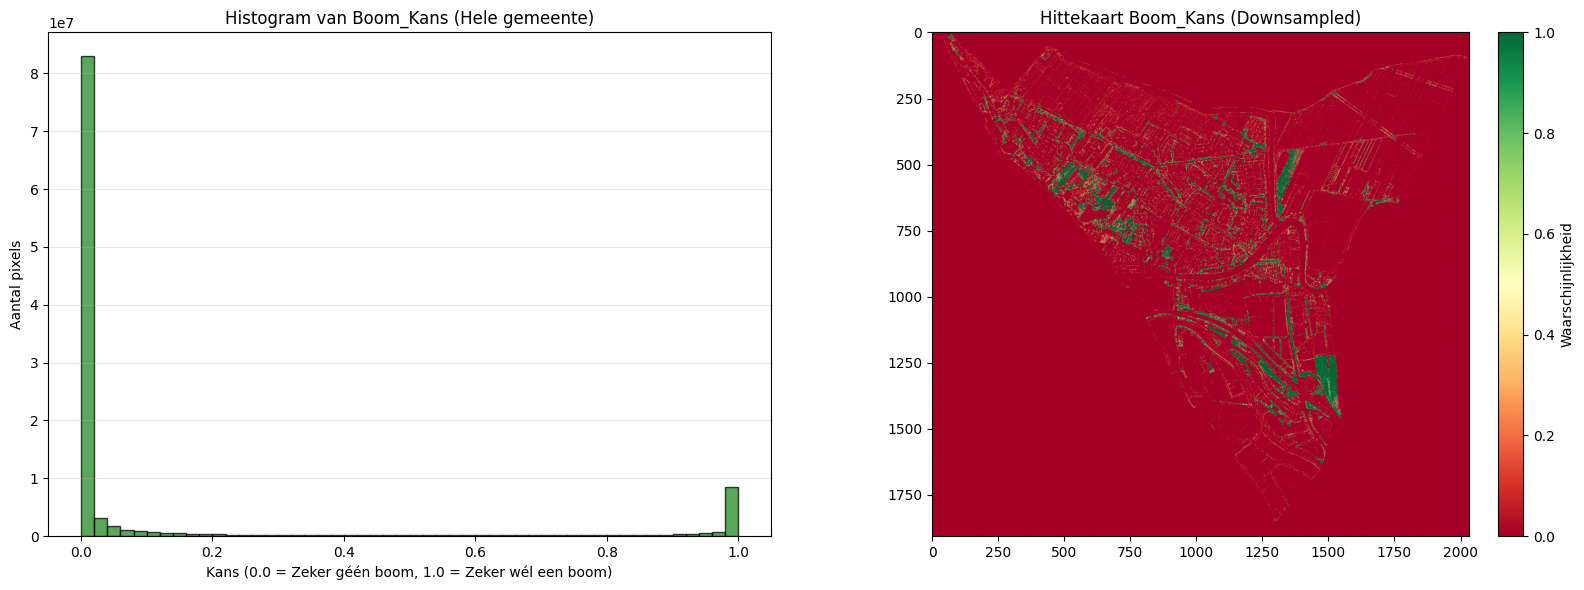

In [85]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

output_11_layers = proces_data_dir / "Alblasserdam_Inference_Stack_22022026.tif"

print("Bezig met inladen van classificatie en kans-lagen...")

with rio.open(output_11_layers) as src:
    # We lezen band 10 (Classificatie) en 11 (Boom_Kans) in hun geheel in.
    # Dit is ongeveer 700MB aan RAM, wat prima past.
    band10_class = src.read(10)
    band11_prob = src.read(11)

# --- 1. STATISTIEKEN BEREKENEN ---
# Filter NoData (-1) en NaNs eruit zodat we alleen naar "echte" voorspellingen kijken
geldige_pixels_mask = (band10_class != -1) & (~np.isnan(band10_class))

valid_classes = band10_class[geldige_pixels_mask]
valid_probs = band11_prob[geldige_pixels_mask]

print(f"\n--- INFERENTIE RESULTATEN ---")
print(f"Totaal aantal voorspelde pixels: {len(valid_classes):,}")
print(f"Unieke klassen gevonden in de kaart: {np.unique(valid_classes)}")
print(f"Boom_Kans range: van {valid_probs.min():.3f} tot {valid_probs.max():.3f}")

# --- 2. PLOTTEN: HISTOGRAM & OVERZICHT ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Het Histogram
ax1.hist(valid_probs, bins=50, color='forestgreen', alpha=0.75, edgecolor='black')
ax1.set_title("Histogram van Boom_Kans (Hele gemeente)")
ax1.set_xlabel("Kans (0.0 = Zeker géén boom, 1.0 = Zeker wél een boom)")
ax1.set_ylabel("Aantal pixels")
ax1.grid(axis='y', alpha=0.3)

# Plot B: Snelle hittekaart (Overzicht)
# We vervangen NaN door -0.1 zodat we de achtergrond makkelijk zwart/grijs kunnen maken
plot_data = np.where(np.isnan(band11_prob), -0.1, band11_prob)

# We downsamplen de array puur voor het plotten (elke 10e pixel), anders crasht je beeldscherm
plot_data_klein = plot_data[::10, ::10]

# RdYlGn = Rood (lage kans), Geel (twijfel), Groen (hoge kans)
im = ax2.imshow(plot_data_klein, cmap='RdYlGn', vmin=0, vmax=1)
ax2.set_title("Hittekaart Boom_Kans (Downsampled)")
fig.colorbar(im, ax=ax2, label="Waarschijnlijkheid", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### segmentatie van bomen

In [ ]:
# #nieuwe Gaussian filter
# gaussian_blur_filter(proces_data_dir / "nDSM_full.tif", 
#                      proces_data_dir / "nDSM_gaus_sig15_b5.tif", 
#                      sigma=1.5, 
#                      buffer=5)

In [ ]:
### gebruiken als de gehele stack in één keer gebruikt kan worden!
import pandas as pd
import numpy as np
import rasterio as rio
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label
from scipy import ndimage as ndi
import geopandas as gpd
from shapely.geometry import shape
import rasterio.features
from scipy import ndimage as ndi
from scipy.ndimage import binary_closing, binary_fill_holes
from skimage.morphology import disk

bomen_raster_alblasserdam_path = proces_data_dir / "Alblasserdam_Inference_Stack_22022026.tif"

with rio.open(bomen_raster_alblasserdam_path) as src:
    # inlezen
    name_to_index = {name: i+1 for i, name in enumerate(src.descriptions)}
    print(name_to_index)

    prob_map = np.nan_to_num(src.read(name_to_index.get('Boom_Kans')), nan=0.0)
    ndsm_gaus = np.nan_to_num(src.read(name_to_index.get('nDSM_Gaussian')), nan=0.0)

    transform = src.transform #bv. | 0.25, 0.00, 105430.00| Met de transform berekent Python tijdens het maken van de polygonen direct de echte coördinaten uit.
    crs = src.crs

    # boom masker maken. 
    # Buiten dit masker mag geen boom getekend worden.
    strenge_drempel = 0.50
    ruime_drempel = 0.20
    ronde_structuur = disk(3)

    seed_mask = (prob_map >= strenge_drempel) & (ndsm_gaus > 2) 
    raw_growth_mask = (prob_map >= ruime_drempel) & (ndsm_gaus > 1)
    closed_mask = binary_closing(raw_growth_mask, structure=ronde_structuur, iterations=2)
    growth_mask = binary_fill_holes(closed_mask)

    print(f"Potentiële boom-pixels (ruim): {np.sum(growth_mask)}")
    print(f"Zekere boom-kernen (streng): {np.sum(seed_mask)}")

    # lokale minima (boomtoppen)
    coords = peak_local_max(ndsm_gaus, min_distance=16, labels=seed_mask) #minimaal 2 meter (4 pixels) uit elkaar
    
    # Maak een masker van alleen de puntjes (de seeds)
    local_maxi = np.zeros_like(ndsm_gaus, dtype=bool)
    local_maxi[tuple(coords.T)] = True

    #label de punten
    markers =ndi.label(local_maxi)[0]

    #watershed
    labels = watershed(-ndsm_gaus, markers, mask=growth_mask)
    print(f"Aantal bomen gevonden: {labels.max()}") 

    # 5. VECTORISEREN (Met filter voor 0!)
    print("Omzetten naar polygonen...")
    
    # We voegen 'if v > 0' toe. 
    # Dit zorgt dat de achtergrond (waarde 0) GEEN polygoon krijgt.
    results = (
        {'properties': {'boom_id': int(v)}, 'geometry': s}
        for i, (s, v) in enumerate(
            rasterio.features.shapes(labels.astype(np.int32), mask=growth_mask, transform=transform)
        )
        if v > 0  # <--- CRUCIALE FIX: Sla de achtergrond over!
    )

    geoms = list(results)
    gdf = gpd.GeoDataFrame.from_features(geoms)

    # CRS instellen
    if crs:
        gdf.set_crs(crs, inplace=True)
    else:
        gdf.set_crs(epsg=28992, inplace=True)

    # 6. HOOGTE BEREKENEN (Gecorrigeerd)
    print("Hoogtes berekenen per boom...")
    
    if not gdf.empty:
        boom_ids = gdf['boom_id'].values
        
        # FIX VOOR ROUND: Zet het resultaat eerst om naar een np.array
        # ndi.maximum geeft een lijst terug, en lijsten kunnen niet afronden.
        raw_heights = ndi.maximum(ndsm_gaus, labels=labels, index=boom_ids)
        gdf['max_height'] = raw_heights.astype(float).round(2)
        
        # De rest van de attributen
        gdf['omtrek_m'] = gdf.geometry.length.astype(float).round(2)
        gdf['area_m2'] = gdf.geometry.area.astype(float).round(2)

        #berekende attributen
        gdf['diameter'] = (gdf.geometry.length.astype(float).round(2)/1.57)**1.429
        
        
        # Filteren op grootte
        gdf_clean = gdf[gdf['area_m2'] > 1.5].copy()
    else:
        print("Geen bomen gevonden om te verwerken.")
        gdf_clean = gdf
    
    

    output_vector = proces_data_dir / "gedetecteerde_bomen_albasserdam_v22022026_16dist3.gpkg"

    gdf_clean.to_file(output_vector, driver="GPKG")

    print(f"Polygonen opgeslagen in {output_vector}")

{'nDSM': 1, 'nDSM_Gaussian': 2, 'NDVI': 3, 'Red': 4, 'Green': 5, 'Blue': 6, 'NIR': 7, 'entropy': 8, 'texture': 9, 'Classificatie': 10, 'Boom_Kans': 11}
Potentiële boom-pixels (ruim): 12563957
Zekere boom-kernen (streng): 8543592


## Synthetische boom creeëren

Omdat we werken op wijkniveau, en van individuele bomen niet weten welke soort het is. Creeëren we een fictieve boom die de verdeling van boomsoorten representeert uit deze regio. Hiervoor gebruiken we onder anderen het rappoort van Natuur & Milieu (2023).

Dit onderzoek maakte gebruik van data van 2,5 miljoen bomen in de openbare ruimte en verschaft ook een top 5 bomensoortenlijst per gemeente. Gemeente Dordrecht dient hier als representatieve gemeente voor Alblasserdam.

De fictieve boom bestaat in dit geval dus: 
* 12% uit Eik, 
* 7% uit Es,
* 5% uit Linde,
* 4% uit schietwilg,
* 4% uit gewone plataan.

We beginnen met boomhoogte (h) als enige 'harde' variabele (uit nDSM).Voor het berekenen van stamdiameter, kroonprojectie en kroonvolume gebruiken we dus gewogen coëfficiënten om vanuit de boomhoogte de andere variabelen mee uit te rekenen.

Risico: Een kleine meetfout kan dus al leiden tot grote afwijkingen tussen de theoretische berekeningen en de daadwerkelijke eigenschappen van de boom. Daarom gebruiken we bandbreedtes (Mean ± SE) om deze onzekerheid te uiten.


1. **Normaliseren van coefficienten**
We normaliseren de gewichten zodat ze samen 1.0 vormen op basis van de 32% geïdentificeerde bomen in Tabel 2 uit Pretzsch et al. (2015). De Mix-Weging:
- Type 1 (Groot/Breed): Linde + Plataan (5%+4%=9%) →w1​≈0.281
- Type 2 (Medium): Es + Wilg (7%+4%=11%) →w2​≈0.344
- Type 3 (Medium/Smal): Eik (12%) →w3​≈0.375
<br>

2. **Van Hoogte (h) naar Stamdiameter (d) <--> Hoogte-Diameter relatie**
- **αh_mix​ = 0.67** The species-specific allometric slope for open-grown trees, α. Geeft hoe snel de hoogte toeneemt ten opzichte van de diameter.Genormaliseerde Alblasserdam-Boom.

- **ah_mix​ = 0.36** De intercept: het punt waar de lijn de y-as snijdt. Het vertegenwoordigt de basisverhouding van de boomvorm.

- a legt de "startwaarde" of de basisproportie van de boom vast, terwijl de α bepaalt hoe die verhouding verandert naarmate de boom groter wordt.

3. **Van diameter (d) naar kroonradius (cr) <--> (Kroonradius relatie)**
- **α_cr_mix​ = 0.691**
- **a_cr_mix​=−0.945**

- Wederom intercept en hellingshoek hoe kroonradius opschaalt met diamter.

4. **Van diameter (d) naar kroonvolume (cv) <--> (Kroonvolume relatie)**
- **α_cv​ ≈ 1.7**
- **a_cv ​≈ 1.1 (let op: dit is ln(a), dus factor ≈3.0)**

### de berekeningen
- **Diameter (d)** = (h/e^ah_mix) ^ 1/αh_mix
- **Kroonradius (cr)** = (e^acr_mix) * d^αcr_mix --> kunnen ook daadwerkelijke radius gebruiken
- **kroonprojectie (cpa)** = π⋅cr^2
- **kroonvolume (cv)** = 3.00⋅d^1.7


In [ ]:
## test_berekeningen
boom_hoogte_dummy = raw_heights[0:2]
boom_hoogte_dummy2 = 10
print(boom_hoogte_dummy)
print(type(raw_heights))

In [ ]:
#inladen boomvector
Alblasserdam_bomen_vector_path = proces_data_dir / "gedetecteerde_bomen_albasserdam_v14.gpkg"
bomen_vect = gpd.read_file(Alblasserdam_bomen_vector_path)
bomen_vect.head(5)

In [ ]:
# --- 1. Parameters (Pretzsch paper) ---
ah_mix, alphah_mix = 0.36, 0.67
acr_mix, alphacr_mix = -0.945, 0.691
ln_acv, alphacv = 1.1, 1.7
factor_cv = np.exp(ln_acv) # ≈ 3.00

# --- 2. Vectorberekening op de GDF ---
# A. Stamdiameter (d)
bomen_vect['diameter_cm'] = (bomen_vect['max_height'] / np.exp(ah_mix)) ** (1 / alphah_mix)

# B. Kroonradius (cr) 
# We kiezen: gebruik de GIS area als die er is, anders de theoretische formule
theoretical_cr = np.exp(acr_mix) * (bomen_vect['diameter_cm'] ** alphacr_mix)
observed_cr = np.sqrt(bomen_vect['area_m2'] / np.pi)

# Optie: GEOMETERIE voor de radius (is nauwkeuriger voor de huidige staat)
bomen_vect['kroonradius_m'] = observed_cr 

# C. Projectie (cpa) en Volume (cv)
bomen_vect['kroonprojectie_m2'] = np.pi * (bomen_vect['kroonradius_m'] ** 2)
bomen_vect['kroonvolume_m3'] = factor_cv * (bomen_vect['diameter_cm'] ** alphacv)

# D. Afronden voor de netheid in QGIS
cols_to_round = ['diameter_cm', 'kroonradius_m', 'kroonprojectie_m2', 'kroonvolume_m3']
bomen_vect[cols_to_round] = bomen_vect[cols_to_round].astype(float).round(2)

### Scenarios voor bandbreedte (voor later)

In [ ]:
def bereken_boom_scenarios(gdf):
    # 1. Basis Parameters (Pretzsch Mix)
    ah_mix, alphah_mix = 0.36, 0.67
    acr_mix, alphacr_mix = -0.945, 0.691
    ln_acv, alphacv = 1.1, 1.7
    
    # 2. Bereken de 'Mean' waarden (Vectorized)
    h_m = gdf['max_height'].values
    d_m = (h_m / np.exp(ah_mix)) ** (1 / alphah_mix)
    
    # Gebruik GIS area voor de actuele radius
    cr_m = np.sqrt(gdf['area_m2'].values / np.pi)
    cpa_m = np.pi * (cr_m ** 2)
    cv_m = np.exp(ln_acv) * (d_m ** alphacv)

    # 3. Definieer SE factoren uit jouw tabel
    se_factors = {
        'Low (-1 SE)':  {'h': 0.90, 'd': 0.75, 'cr': 0.74, 'cpa': 0.48, 'cv': 0.48},
        'Mean':         {'h': 1.00, 'd': 1.00, 'cr': 1.00, 'cpa': 1.00, 'cv': 1.00},
        'High (+1 SE)': {'h': 1.10, 'd': 1.25, 'cr': 1.26, 'cpa': 1.52, 'cv': 1.52}
    }

    # 4. Maak de drie scenario-versies van de GDF
    scenarios = []
    for name, f in se_factors.items():
        s_gdf = gdf.copy()
        s_gdf['scenario'] = name
        s_gdf['h_final'] = (h_m * f['h']).round(2)
        s_gdf['d_cm'] = (d_m * f['d']).round(2)
        s_gdf['cr_m'] = (cr_m * f['cr']).round(2)
        s_gdf['cpa_m2'] = (cpa_m * f['cpa']).round(2)
        s_gdf['cv_m3'] = (cv_m * f['cv']).round(2)
        scenarios.append(s_gdf)

    # 5. Voeg alles samen (Long format: 3 rijen per boom)
    gdf_final = pd.concat(scenarios, ignore_index=True)
    return gdf_final

# Gebruik:
gdf_boom_bandbreedte = bereken_boom_scenarios(bomen_vect)

In [ ]:
print(gdf_boom_bandbreedte.shape)
print(bomen_vect.shape)

https://medium.com/@apratimonline/deep-dive-into-unsupervised-classification-of-satellite-images-k-means-pca-and-spectral-indices-442a5dc23219

### Scoping out the main ecosystem services. Ophalen data van biofysieke flows van bomen:
* CO2 opslag
* waterretentie
* Luchtvervuiling opname
* geluidsreductie
* Aestethiek
* Recreationele waarde
* Lokaal microklimaat (afkoeling)


### Ophalen monetaire kentallen ecosysteemdiensten:
* CO2 opslag
* waterretentie
* Luchtvervuiling opname
* geluidsreductie
* Aestethiek
* Recreationele waarde
* Lokaal microklimaat (afkoeling)



In [ ]:
BASE = "https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1"
buurten_url = f"{BASE}/collections/buurten/items"

params = {
    "f": "json",
    "gemeentenaam": "Alblasserdam",  # filter to Alblasserdam
    "limit": 1000
}

response = requests.get(buurten_url, params=params)


if response.status_code == 200:
    raw = response.json()
else:
    print(f'Errro: {response.status_code}')

buurten_Alblasserdam = gpd.GeoDataFrame.from_features(raw["features"], crs = "EPSG: 28992")

In [ ]:
print(buurten_Alblasserdam.shape)
print(buurten_Alblasserdam.groupby('buurtnaam')['aantal_inwoners'].sum().sort_values(ascending=False))
buurten_Alblasserdam.plot(column='aantal_inwoners', legend=True, cmap='viridis')

### interactieve kaart - voor later

In [ ]:
import leafmap
# url = "https://fsn1.your-objectstorage.com/hwh-ortho/2022/Ortho/4/70/beelden_tif_tegels/2022_105000_431000_RGB_hrl.tif"
m = leafmap.Map(center=(40, -100), zoom=4)

tif_path = proces_data_dir / "nDSM_full.tif"

m.add_raster(
    str(tif_path),
    layer_name="alblasserdam_bomen",
    colormap="terrain",
    opacity=0.95,
)

m